In [26]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import scipy
import seaborn as sns
import IPython
import pandas as pd
import sklearn
import torchvision
import torchaudio

In [3]:
_base = os.getcwd()
_project_root = (
    os.path.dirname(_base) if os.path.basename(_base).lower() == "training" else _base
)
ALL_EMOTIONS_CSV = os.path.join(_project_root, "dataset", "all_emotions.csv")
ALL_EMOTIONS_CSV = os.path.normpath(ALL_EMOTIONS_CSV)

ALL_EMOTIONS_CSV

'd:\\Code\\Python\\Emotion_detecting\\dataset\\all_emotions.csv'

In [5]:
df = pd.read_csv(ALL_EMOTIONS_CSV)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 57913 entries, 0 to 57912
Data columns (total 49 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   F0_mean                 54485 non-null  float64
 1   F0_std                  54485 non-null  float64
 2   F0_range                54485 non-null  float64
 3   Energy_ mean            54485 non-null  float64
 4   Energy_ std             54485 non-null  float64
 5   ZCR_mean                54485 non-null  float64
 6   ZCR_std                 54485 non-null  float64
 7   Spectral_centroid_mean  54485 non-null  float64
 8   Spectral_centroid_std   54485 non-null  float64
 9   Spectral_flux_mean      54485 non-null  float64
 10  MFCC_C0_mean            54485 non-null  float64
 11  MFCC_C1_mean            54485 non-null  float64
 12  MFCC_C2_mean            54485 non-null  float64
 13  MFCC_C3_mean            54485 non-null  float64
 14  MFCC_C4_mean            54485 non-null  float64
 

In [6]:
df.describe()

,F0_mean,F0_std,F0_range,Energy_ mean,Energy_ std,ZCR_mean,ZCR_std,Spectral_centroid_mean,Spectral_centroid_std,Spectral_flux_mean,...,Delta_MFCC_C2_mean,Delta_MFCC_C3_mean,Delta_MFCC_C4_mean,Delta_MFCC_C5_mean,Delta_MFCC_C0_std,Delta_MFCC_C1_std,Delta_MFCC_C2_std,Delta_MFCC_C3_std,Delta_MFCC_C4_std,Delta_MFCC_C5_std
count,54485.000000,54485.000000,54485.000000,54485.000000,54485.000000,54485.000000,54485.000000,54485.000000,54485.000000,54485.000000,...,54485.000000,54485.000000,54485.000000,54485.000000,54485.000000,54485.000000,54485.000000,54485.000000,54485.000000,54485.000000
mean,205.613005,52.312777,172.564908,0.023716,0.021837,0.124542,0.089615,2266.268635,922.341524,0.296512,...,-0.035194,-0.007205,0.025366,-0.012671,10.903517,5.345412,4.608628,3.607400,3.216849,2.818085
std,115.277987,91.734619,261.367990,0.023553,0.025184,0.085471,0.063706,1189.976223,621.025052,0.311927,...,0.232973,0.174379,0.168997,0.115846,5.293045,2.313962,1.900098,1.428755,1.182722,1.020924
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-2.814082,-2.113490,-1.854221,-1.266125,0.000006,0.000000,0.000000,0.000000,0.000000,0.000000
25%,137.953601,16.494055,61.046618,0.009555,0.006662,0.056431,0.033306,1287.936274,429.720780,0.172271,...,-0.079507,-0.059144,-0.031940,-0.049782,6.831969,3.622323,3.271949,2.656204,2.355057,2.066060
50%,193.042331,32.982320,117.841272,0.015605,0.012917,0.088960,0.077713,1723.600403,743.696843,0.230257,...,-0.010049,-0.005500,0.008841,-0.005118,10.222263,4.796132,4.578399,3.396323,3.133247,2.720504
75%,244.303891,55.435179,189.777313,0.029039,0.026550,0.188398,0.131303,3187.278004,1315.596491,0.291781,...,0.043552,0.043772,0.058470,0.033632,14.492401,6.695895,5.926492,4.334468,4.009305,3.507054
max,2028.394580,879.656827,2027.598131,0.228895,0.219936,0.492869,0.336733,7416.297748,4819.783067,3.990659,...,2.080793,1.396789,1.676911,1.067473,34.509930,18.036146,12.904985,9.855183,8.510065,7.087403


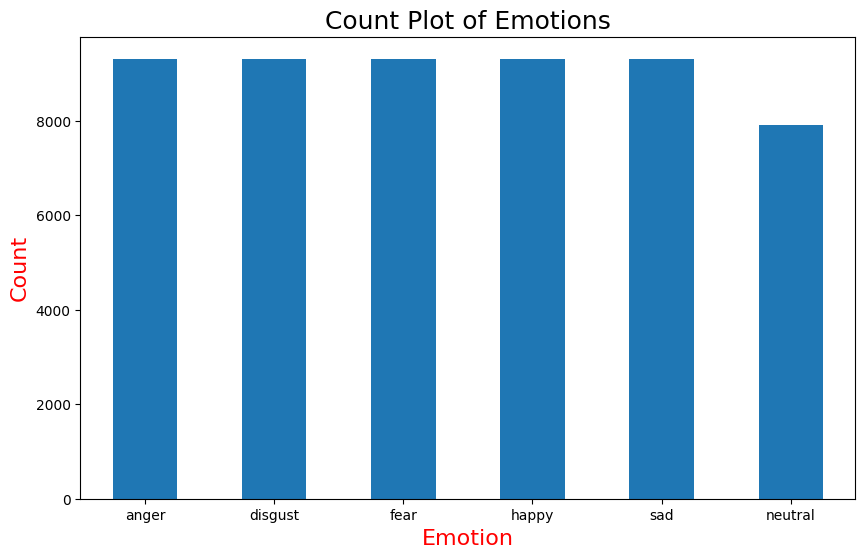

In [24]:
plt.figure(figsize=(10, 6))
df["label"].value_counts().plot(kind="bar")
plt.xlabel("Emotion" , color="red" , fontsize=16)
plt.ylabel("Count" , color="red" , fontsize=16)
plt.title("Count Plot of Emotions"  , fontsize=18)
plt.xticks(rotation=0)
plt.show()

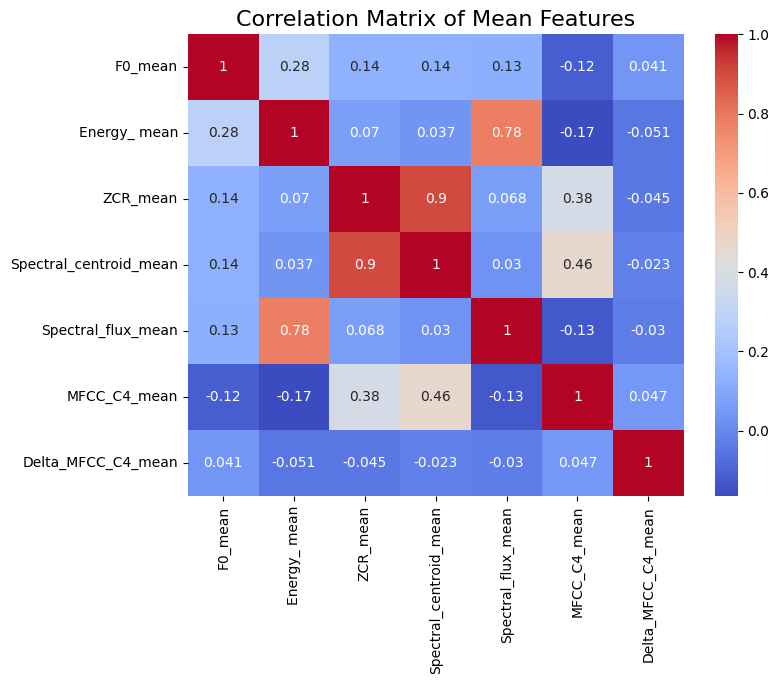

In [37]:
plt.figure(figsize=(8, 6))
cols_mean = [
    "F0_mean",
    "Energy_ mean",
    "ZCR_mean",
    "Spectral_centroid_mean",
    "Spectral_flux_mean",
    "MFCC_C4_mean",
    "Delta_MFCC_C4_mean",
]

corr_matrix_mean = df[cols_mean].corr()
sns.heatmap(corr_matrix , annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Mean Features" , fontsize=16)
plt.show()

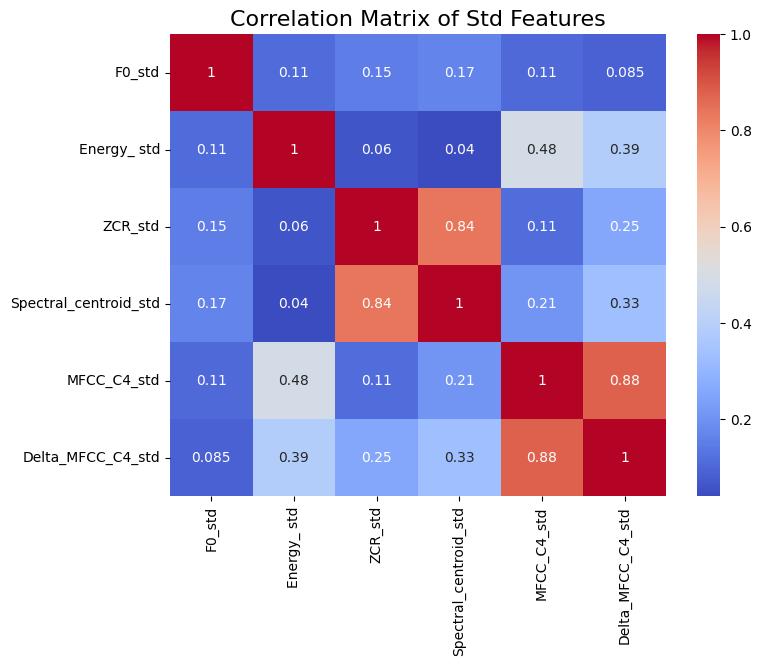

In [39]:
plt.figure(figsize=(8, 6))
cols_std = [
    "F0_std",
    "Energy_ std",
    "ZCR_std",
    "Spectral_centroid_std",
    "MFCC_C4_std",
    "Delta_MFCC_C4_std",
]

corr_matrix_std = df[cols_std].corr()
sns.heatmap(corr_matrix_std , annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Std Features" , fontsize=16)
plt.show()

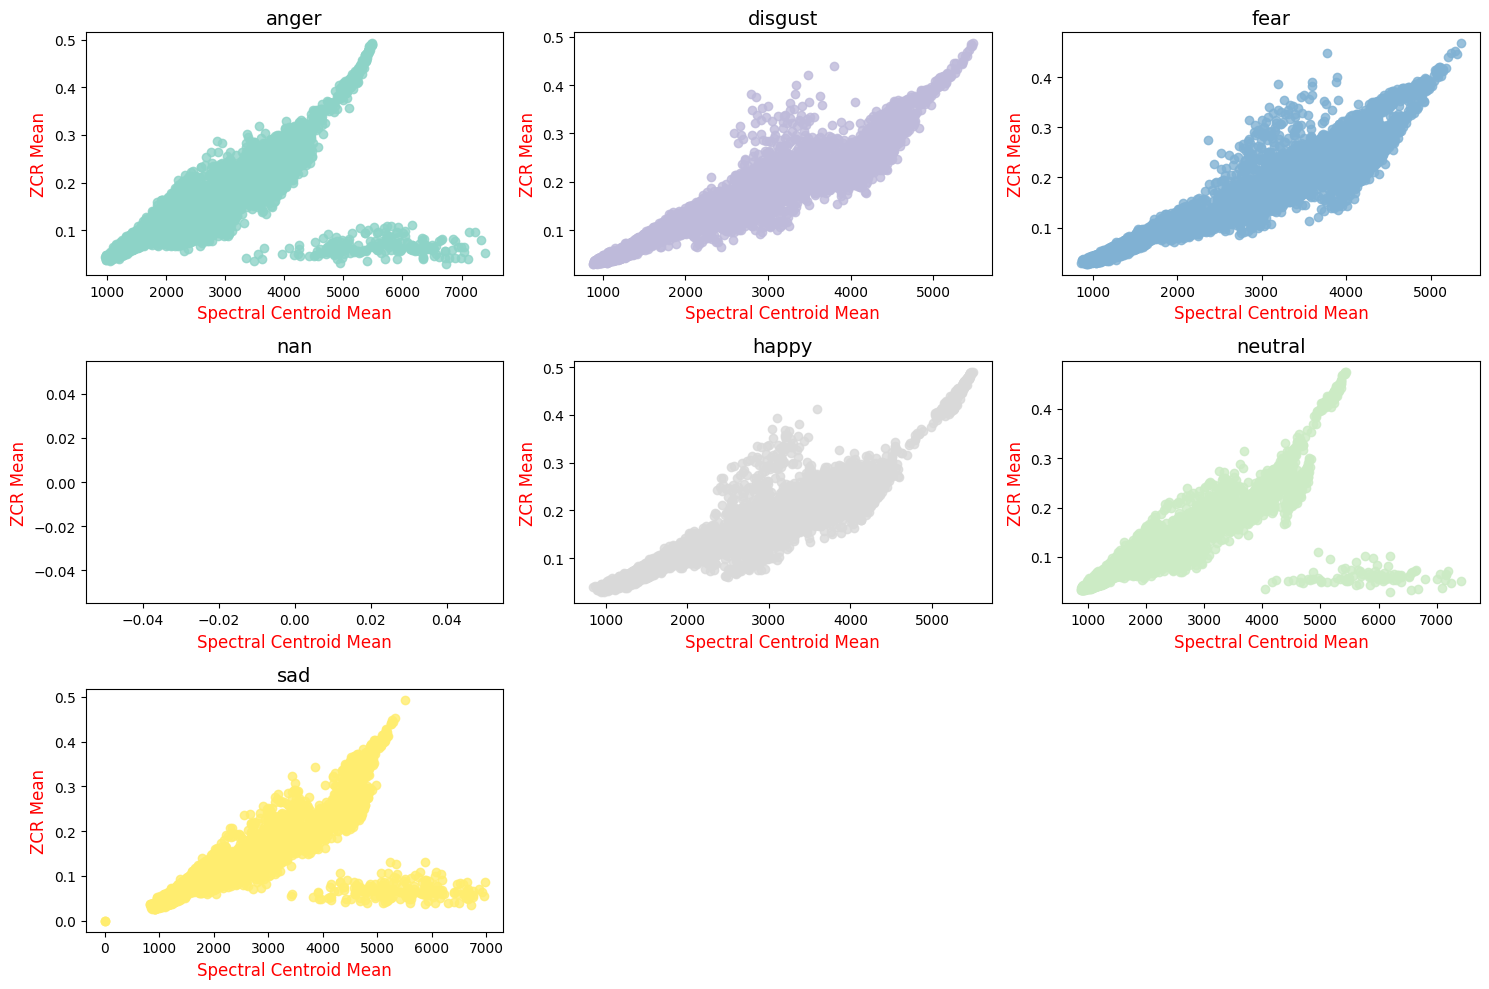

In [ ]:
emotions = df["label"].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(emotions)))

n_emotions = len(emotions)
ncols = 3
nrows = (n_emotions + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 10))
axes = axes.flatten()

for i, emotion in enumerate(emotions):
    subset = df[df["label"] == emotion]
    axes[i].scatter(subset["Spectral_centroid_mean"], subset["ZCR_mean"], color=colors[i], alpha=0.8)
    axes[i].set_title(f"{emotion}", fontsize=14)
    axes[i].set_xlabel("Spectral Centroid Mean", color="red", fontsize=12)
    axes[i].set_ylabel("ZCR Mean", color="red", fontsize=12)


for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

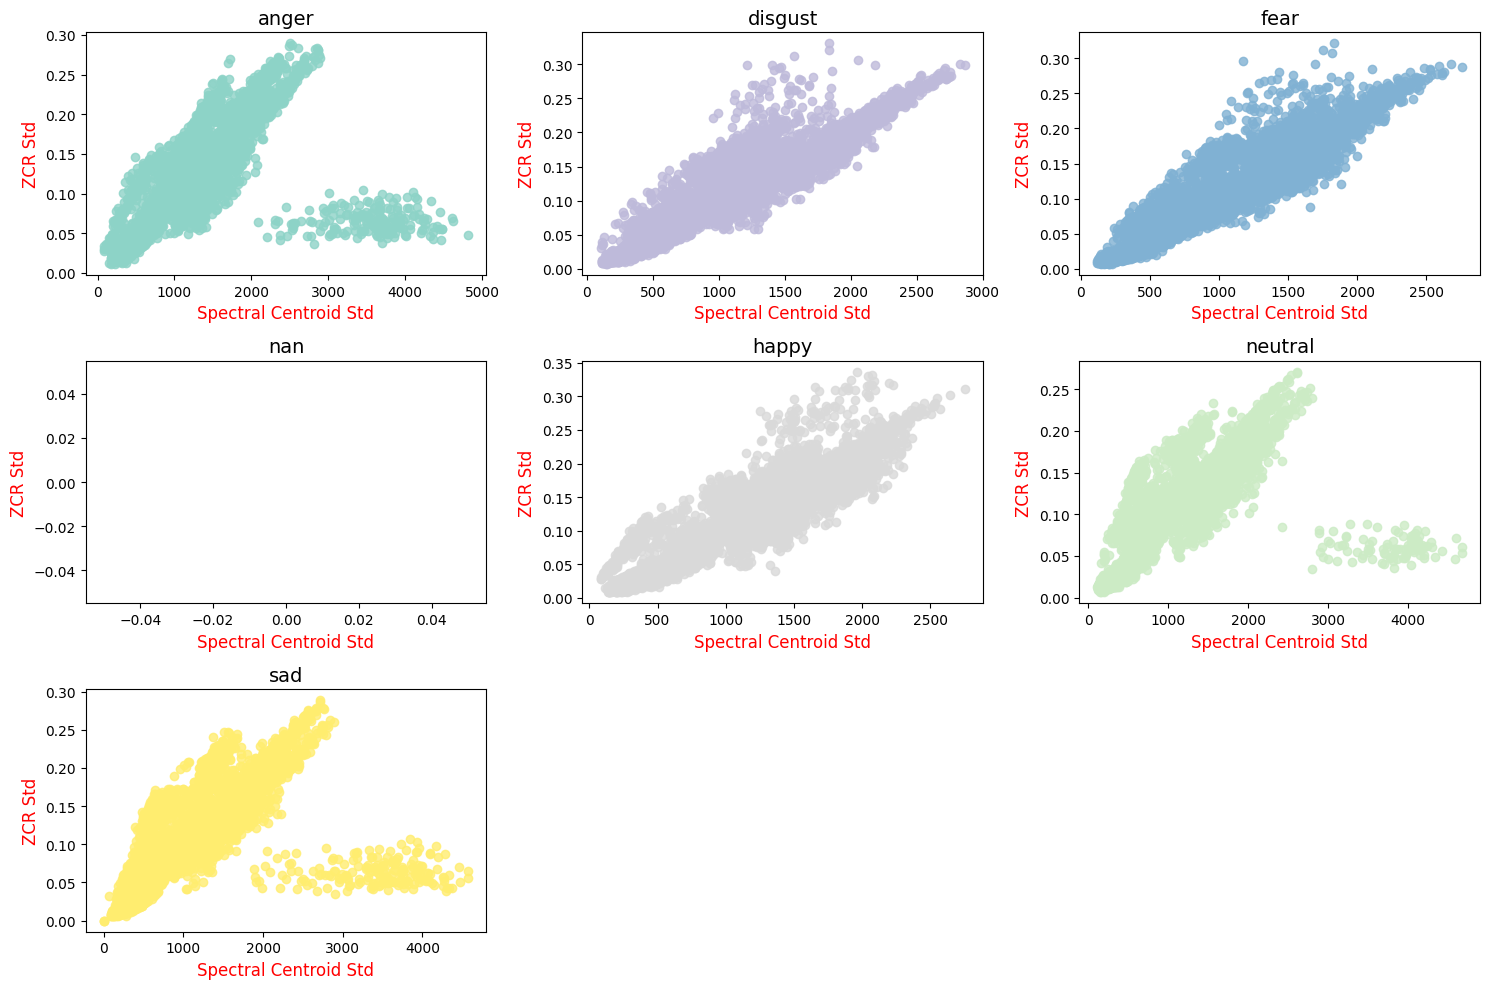

In [58]:
emotions = df["label"].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(emotions)))

n_emotions = len(emotions)
ncols = 3
nrows = (n_emotions + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 10))
axes = axes.flatten()

for i, emotion in enumerate(emotions):
    subset = df[df["label"] == emotion]
    axes[i].scatter(subset["Spectral_centroid_std"], subset["ZCR_std"], color=colors[i], alpha=0.8)
    axes[i].set_title(f"{emotion}", fontsize=14)
    axes[i].set_xlabel("Spectral Centroid Std", color="red", fontsize=12)
    axes[i].set_ylabel("ZCR Std", color="red", fontsize=12)


for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()